# Pacotes


In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, normaltest

from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# Data Wrangling


In [3]:
df_imoveis = pd.read_csv('Bens_Imoveis_Consolidado.csv', sep=';', encoding='latin1')
print(f"Linhas: {df_imoveis.shape[0]:,} | Colunas: {df_imoveis.shape[1]}")
df_imoveis.tail()

Linhas: 526,007 | Colunas: 18


,#Nome_da_Administradora,CNPJ_da_Administradora,Data_base,Código_do_grupo,Código_do_segmento,Número_da_assembléia_geral_ordinária,Valor_médio_do_bem,Índice_de_correção,Taxa_de_administração,Prazo_do_grupo_em_meses,Quantidade_de_cotas_ativas_em_dia,Quantidade_de_cotas_ativas_contempladas_inadimplentes,Quantidade_de_cotas_ativas_não_contempladas_inadimplentes,Quantidade_de_cotas_ativas_contempladas_no_mês,Quantidade_de_cotas_excluídas,Quantidade_de_cotas_ativas_quitadas,Quantidade_de_cotas_ativas_com_crédito_pendente_de_utilização,Arquivo_Origem
526002,SERELLO CONSORCIOS,94187879,202604,5101,1,18,"493989,80",2,"21,67595",220,1377,0,321,3,680,0,29,202604Bens_Imoveis_Grupos.csv
526003,SERELLO CONSORCIOS,94187879,202604,5102,1,13,"115659,57",2,"21,87966",220,2499,4,422,5,888,0,41,202604Bens_Imoveis_Grupos.csv
526004,SERELLO CONSORCIOS,94187879,202604,5103,1,8,"526388,13",2,"21,50395",220,1634,0,140,4,249,0,16,202604Bens_Imoveis_Grupos.csv
526005,SERELLO CONSORCIOS,94187879,202604,5104,1,7,"105572,43",2,"21,21293",220,2612,1,294,6,490,0,28,202604Bens_Imoveis_Grupos.csv
526006,SERELLO CONSORCIOS,94187879,202604,5105,1,5,"227199,11",2,"21,91174",220,1549,0,197,2,207,0,8,202604Bens_Imoveis_Grupos.csv


In [4]:
df_imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526007 entries, 0 to 526006
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count   Dtype 
---  ------                                                         --------------   ----- 
 0   #Nome_da_Administradora                                        526007 non-null  object
 1   CNPJ_da_Administradora                                         526007 non-null  int64 
 2   Data_base                                                      526007 non-null  int64 
 3   Código_do_grupo                                                526007 non-null  object
 4   Código_do_segmento                                             526007 non-null  int64 
 5   Número_da_assembléia_geral_ordinária                           526007 non-null  int64 
 6   Valor_médio_do_bem                                             526007 non-null  object
 7   Índice_de_correção                                      

In [5]:
novos_nomes = [
    'nome_da_administradora',
    'cnpj_da_administradora',
    'data_base',
    'grupo',
    'segmento',
    'numero_da_assembleia_geral_ordinaria',
    'valor_medio_do_bem',
    'indice_de_correcao',
    'taxa_de_administracao',
    'prazo_do_grupo_em_meses',
    'quantidade_de_cotas_ativas_em_dia',
    'quantidade_de_cotas_ativas_contempladas_inadimplentes',
    'quantidade_de_cotas_ativas_nao_contempladas_inadimplentes',
    'quantidade_de_cotas_ativas_contempladas_no_mes',
    'quantidade_de_cotas_excluidas',
    'quantidade_de_cotas_ativas_quitadas',
    'quantidade_de_cotas_ativas_com_credito_pendente_de_utilizacao',
    'arquivo_origem'
]

df_imoveis.columns = novos_nomes
df_imoveis.head()

,nome_da_administradora,cnpj_da_administradora,data_base,grupo,segmento,numero_da_assembleia_geral_ordinaria,valor_medio_do_bem,indice_de_correcao,taxa_de_administracao,prazo_do_grupo_em_meses,quantidade_de_cotas_ativas_em_dia,quantidade_de_cotas_ativas_contempladas_inadimplentes,quantidade_de_cotas_ativas_nao_contempladas_inadimplentes,quantidade_de_cotas_ativas_contempladas_no_mes,quantidade_de_cotas_excluidas,quantidade_de_cotas_ativas_quitadas,quantidade_de_cotas_ativas_com_credito_pendente_de_utilizacao,arquivo_origem
0,COPLAVEN - IMPEDIDA CRIAR NOVOS GRUPOS,1471788,199701,00C01,1,80,"46759,00",3,"11,00000",100,186,9,1,2,561,26,7,199701Bens_Imoveis_Grupos.csv
1,COPLAVEN - IMPEDIDA CRIAR NOVOS GRUPOS,1471788,199701,00C07,1,38,"9923,00",3,"11,00000",100,132,4,5,1,837,1,4,199701Bens_Imoveis_Grupos.csv
2,CCA ADM CONSORCIO LTDA - IMPEDIDA CRIAR NOVOS GRUPOS,2790467,199701,01I01,1,21,"35624,00",1,"9,90000",80,107,10,36,1,302,2,0,199701Bens_Imoveis_Grupos.csv
3,CCA ADM CONSORCIO LTDA - IMPEDIDA CRIAR NOVOS GRUPOS,2790467,199701,01I02,1,13,"38045,00",1,"9,50000",100,145,4,46,2,364,2,0,199701Bens_Imoveis_Grupos.csv
4,ACAUA ADM.CONS. - IMPEDIDA CRIAR NOVOS GRUPOS,15939432,199701,51,1,48,"33720,00",3,"12,00000",100,20,15,4,0,166,3,0,199701Bens_Imoveis_Grupos.csv


In [6]:
colunas_numericas = [
    'taxa_de_administracao', 'prazo_do_grupo_em_meses', 'valor_medio_do_bem',
    'numero_da_assembleia_geral_ordinaria',
    'quantidade_de_cotas_ativas_em_dia', 'quantidade_de_cotas_ativas_contempladas_inadimplentes',
    'quantidade_de_cotas_ativas_nao_contempladas_inadimplentes',
    'quantidade_de_cotas_ativas_contempladas_no_mes',
    'quantidade_de_cotas_ativas_quitadas', 'quantidade_de_cotas_excluidas',
    'quantidade_de_cotas_ativas_com_credito_pendente_de_utilizacao'
]

for col in colunas_numericas:
    if col in df_imoveis.columns:
        if df_imoveis[col].dtype == 'object':
            df_imoveis[col] = (
                df_imoveis[col]
                .astype(str)
                .str.replace('.', '', regex=False)
                .str.replace(',', '.', regex=False)
            )
        df_imoveis[col] = pd.to_numeric(df_imoveis[col], errors='coerce').fillna(0)

print("Conversao numerica concluida.")
df_imoveis[colunas_numericas].describe().T

Conversao numerica concluida.


,count,mean,std,min,25%,50%,75%,max
taxa_de_administracao,526007.0,17.536352,4.301108,0.0,15.67593,17.5,20.00,156.0
prazo_do_grupo_em_meses,526007.0,153.768817,76.089840,0.0,120.00000,144.0,180.00,45162.0
valor_medio_do_bem,526007.0,128858.782977,128265.381270,0.0,51896.11500,91634.0,158400.18,13761587.0
numero_da_assembleia_geral_ordinaria,526007.0,62.347611,43.111311,0.0,26.00000,57.0,93.00,4443.0
quantidade_de_cotas_ativas_em_dia,526007.0,427.950658,458.729381,0.0,209.00000,335.0,513.00,9883.0
quantidade_de_cotas_ativas_contempladas_inadimplentes,526007.0,12.790168,17.089052,0.0,3.00000,8.0,17.00,560.0
quantidade_de_cotas_ativas_nao_contempladas_inadimplentes,526007.0,35.479975,75.668113,0.0,4.00000,14.0,38.00,3537.0
quantidade_de_cotas_ativas_contempladas_no_mes,526007.0,3.206961,4.842607,0.0,1.00000,3.0,4.00,439.0
quantidade_de_cotas_ativas_quitadas,526007.0,65.521465,125.833014,0.0,1.00000,15.0,89.00,8999.0
quantidade_de_cotas_excluidas,526007.0,693.475330,839.988851,0.0,230.00000,438.0,845.00,15589.0


In [7]:
df_imoveis['data_base'] = pd.to_datetime(
    df_imoveis['data_base'].astype(str), format='%Y%m', errors='coerce'
)

df_imoveis['cnpj_da_administradora'] = (
    df_imoveis['cnpj_da_administradora'].astype(str).str.zfill(14).astype('category')
)

df_imoveis['nome_da_administradora'] = (
    df_imoveis['nome_da_administradora'].astype(str).str.strip().str.upper()
)

df_imoveis['grupo'] = df_imoveis['grupo'].astype(str).str.strip()

df_imoveis['segmento'] = 'Bens Imóveis'
df_imoveis['segmento'] = df_imoveis['segmento'].astype('category')

df_imoveis['arquivo_origem'] = df_imoveis['arquivo_origem'].astype('category')

print("Tipagem e padronizacao de texto concluidas.")

Tipagem e padronizacao de texto concluidas.


In [8]:
mapa_indices = {
    '1': 'IPCA',
    '2': 'INPC',
    '3': 'INCC',
    '4': 'CUB',
    '5': 'IGP-M',
    '6': 'FIPE',
    '7': 'INCC-M',
    '99': 'Outros / Não Informado',
    '0': 'Sem Correção'
}

serie_indice = df_imoveis['indice_de_correcao'].astype(str)
df_imoveis['indice_de_correcao'] = (
    serie_indice.map(mapa_indices).fillna(serie_indice).astype('category')
)

print(df_imoveis['indice_de_correcao'].value_counts())

indice_de_correcao
INCC                      350327
Outros / Não Informado     63918
CUB                        55979
IPCA                       41907
INPC                        9916
FIPE                        3521
IGP-M                        436
Sem Correção                   2
INCC-M                         1
Name: count, dtype: int64


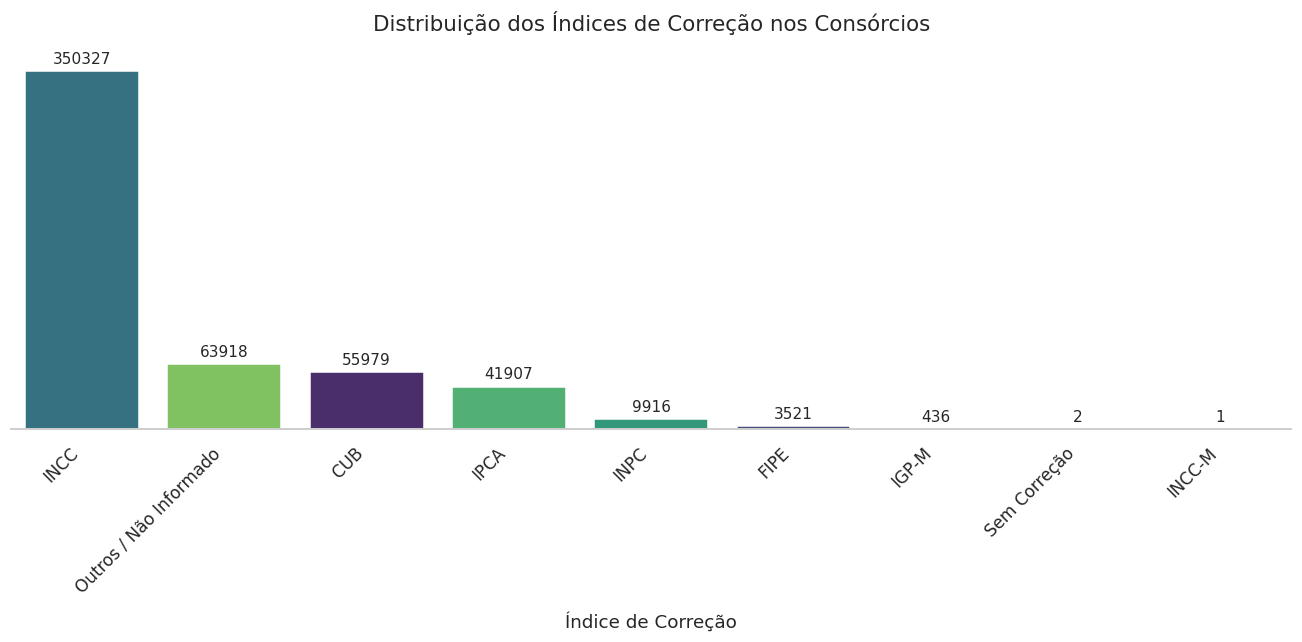

In [9]:
plt.figure(figsize=(12, 6))
ordem_indices = df_imoveis['indice_de_correcao'].value_counts().index

ax = sns.countplot(
    data=df_imoveis,
    x='indice_de_correcao',
    order=ordem_indices,
    hue='indice_de_correcao',
    legend=False,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('Distribuição dos Índices de Correção nos Consórcios', fontsize=14, pad=15)
plt.xlabel('Índice de Correção', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
sns.despine(left=True)
ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
df_imoveis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526007 entries, 0 to 526006
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count   Dtype         
---  ------                                                         --------------   -----         
 0   nome_da_administradora                                         526007 non-null  object        
 1   cnpj_da_administradora                                         526007 non-null  category      
 2   data_base                                                      526007 non-null  datetime64[ns]
 3   grupo                                                          526007 non-null  object        
 4   segmento                                                       526007 non-null  category      
 5   numero_da_assembleia_geral_ordinaria                           526007 non-null  int64         
 6   valor_medio_do_bem                                             526007 non-null  floa

# Engenharia de Features


In [12]:
df_imoveis['total_cotas'] = (
    df_imoveis['quantidade_de_cotas_ativas_em_dia'] +
    df_imoveis['quantidade_de_cotas_ativas_contempladas_inadimplentes'] +
    df_imoveis['quantidade_de_cotas_ativas_nao_contempladas_inadimplentes'] +
    df_imoveis['quantidade_de_cotas_ativas_quitadas']
)

df_imoveis['total_cotas_ativas'] = (
    df_imoveis['quantidade_de_cotas_ativas_em_dia'] +
    df_imoveis['quantidade_de_cotas_ativas_contempladas_inadimplentes'] +
    df_imoveis['quantidade_de_cotas_ativas_nao_contempladas_inadimplentes']
)

df_imoveis['prop_inadimplencia'] = np.where(
    df_imoveis['total_cotas'] > 0,
    df_imoveis['quantidade_de_cotas_ativas_contempladas_inadimplentes'] / df_imoveis['total_cotas'],
    0
)

df_imoveis['prop_excluidas'] = np.where(
    df_imoveis['total_cotas'] > 0,
    df_imoveis['quantidade_de_cotas_excluidas'] / df_imoveis['total_cotas'],
    0
)

df_imoveis['prop_nao_inadimplencia'] = 1 - df_imoveis['prop_inadimplencia']
df_imoveis['prop_nao_excluidas'] = 1 - df_imoveis['prop_excluidas']

df_imoveis[['total_cotas', 'total_cotas_ativas', 'prop_inadimplencia', 'prop_excluidas']].describe()

,total_cotas,total_cotas_ativas,prop_inadimplencia,prop_excluidas
count,526007.000000,526007.000000,526007.000000,526007.000000
mean,541.742266,476.220801,0.030793,1.636474
std,549.219886,511.761837,0.042861,4.477587
min,0.000000,0.000000,0.000000,0.000000
25%,277.000000,238.000000,0.006276,0.551890
50%,431.000000,359.000000,0.019435,1.030075
75%,645.000000,562.000000,0.037901,1.760479
max,18518.000000,9997.000000,1.000000,734.000000


In [13]:
qtd_negativos = (df_imoveis[['prop_inadimplencia', 'prop_excluidas']] < 0).sum()
print("Quantidade de registros negativos por coluna:")
print(qtd_negativos)

Quantidade de registros negativos por coluna:
prop_inadimplencia    0
prop_excluidas        0
dtype: int64


In [14]:
def classificar_fase_metodologica(row):
    idade_meses = row['numero_da_assembleia_geral_ordinaria']
    prazo_total = row['prazo_do_grupo_em_meses']

    if prazo_total == 0:
        return '2. Maturidade Operacional'

    percentual_concluido = idade_meses / prazo_total

    if percentual_concluido <= 0.20:
        return '1. Constituição (Até 20%)'
    elif percentual_concluido >= 0.85:
        return '3. Encerramento (Últimos 15%)'
    else:
        return '2. Maturidade Operacional'

df_imoveis['fase_do_grupo'] = (
    df_imoveis.apply(classificar_fase_metodologica, axis=1).astype('category')
)

df_imoveis['fase_do_grupo'].value_counts()

fase_do_grupo
2. Maturidade Operacional        311295
1. Constituição (Até 20%)        151608
3. Encerramento (Últimos 15%)     63104
Name: count, dtype: int64

In [16]:
analise_fases = df_imoveis.groupby('fase_do_grupo', observed=True).agg(
    Qtd_Grupos=('grupo', 'count')
)
analise_fases['Percentual (%)'] = (
    analise_fases['Qtd_Grupos'] / analise_fases['Qtd_Grupos'].sum() * 100
).round(2)
analise_fases = analise_fases.sort_values('Percentual (%)', ascending=False)
print(analise_fases)

                               Qtd_Grupos  Percentual (%)
fase_do_grupo                                            
2. Maturidade Operacional          311295           59.18
1. Constituição (Até 20%)          151608           28.82
3. Encerramento (Últimos 15%)       63104           12.00


# Índice de Saúde Financeira


In [18]:
colunas_saude = ['prop_inadimplencia', 'prop_excluidas']

for col in colunas_saude:
    df_imoveis[f'{col}_padronizado'] = df_imoveis.groupby(
        ['cnpj_da_administradora', 'fase_do_grupo'], observed=True
    )[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    ).fillna(0)

colunas_padronizadas = [f'{col}_padronizado' for col in colunas_saude]
df_imoveis[colunas_padronizadas].describe()

,prop_inadimplencia_padronizado,prop_excluidas_padronizado
count,526007.000000,5.260070e+05
mean,0.000000,3.458109e-17
std,0.999238,9.992440e-01
min,-3.397460,-4.094606e+00
25%,-0.680822,-6.050975e-01
50%,-0.226936,-1.159234e-01
75%,0.479335,5.042724e-01
max,34.747561,3.497892e+01


In [19]:
pca = PCA(n_components=1)
indice_cientifico = pca.fit_transform(df_imoveis[colunas_padronizadas])

if pca.components_[0][0] > 0:
    indice_cientifico = -indice_cientifico

def sigmoide_0_100(x):
    return 100 / (1 + np.exp(-x / np.std(x)))

df_imoveis['Score_Saude_Financeira'] = sigmoide_0_100(indice_cientifico)
df_imoveis['target_em_risco'] = (df_imoveis['Score_Saude_Financeira'] <= 40).astype(int)

df_imoveis[['Score_Saude_Financeira', 'target_em_risco']].describe()

,Score_Saude_Financeira,target_em_risco
count,5.260070e+05,526007.000000
mean,5.083092e+01,0.294829
std,1.969607e+01,0.455966
min,2.988771e-11,0.000000
25%,3.649099e+01,0.000000
50%,5.338958e+01,0.000000
75%,6.651313e+01,1.000000
max,9.814923e+01,1.000000


In [20]:
variancia_explicada = pca.explained_variance_ratio_[0] * 100

print("--- RELATÓRIO DE AUDITORIA DO MODELO PCA ---")
print(f"O score explica {variancia_explicada:.2f}% da variação conjunta dos indicadores de saúde.\n")

print("Pesos (loadings) atribuídos pelo algoritmo:")
sinal = -1 if pca.components_[0][0] > 0 else 1
for col, peso in zip(colunas_saude, pca.components_[0]):
    print(f" -> {col}: {peso * sinal:.4f}")

--- RELATÓRIO DE AUDITORIA DO MODELO PCA ---
O score explica 60.79% da variação conjunta dos indicadores de saúde.

Pesos (loadings) atribuídos pelo algoritmo:
 -> prop_inadimplencia: -0.7071
 -> prop_excluidas: -0.7071


# Análise estatística


In [22]:
variaveis_continuas = [
    'taxa_de_administracao', 'valor_medio_do_bem', 'prazo_do_grupo_em_meses',
    'total_cotas', 'prop_inadimplencia', 'prop_excluidas', 'Score_Saude_Financeira'
]

resumo = df_imoveis[variaveis_continuas].describe().T
resumo['cv_%'] = (df_imoveis[variaveis_continuas].std() / df_imoveis[variaveis_continuas].mean() * 100)
resumo['assimetria'] = df_imoveis[variaveis_continuas].apply(lambda s: stats.skew(s))
resumo['curtose'] = df_imoveis[variaveis_continuas].apply(lambda s: stats.kurtosis(s))
resumo.round(3)

,count,mean,std,min,25%,50%,75%,max,cv_%,assimetria,curtose
taxa_de_administracao,526007.0,17.536,4.301,0.0,15.676,17.500,20.000,1.560000e+02,24.527,-0.554,8.570
valor_medio_do_bem,526007.0,128858.783,128265.381,0.0,51896.115,91634.000,158400.180,1.376159e+07,99.539,10.144,648.929
prazo_do_grupo_em_meses,526007.0,153.769,76.090,0.0,120.000,144.000,180.000,4.516200e+04,49.483,393.671,232738.667
total_cotas,526007.0,541.742,549.220,0.0,277.000,431.000,645.000,1.851800e+04,101.380,7.747,115.207
prop_inadimplencia,526007.0,0.031,0.043,0.0,0.006,0.019,0.038,1.000000e+00,139.190,4.646,41.112
prop_excluidas,526007.0,1.636,4.478,0.0,0.552,1.030,1.760,7.340000e+02,273.612,62.668,8623.446
Score_Saude_Financeira,526007.0,50.831,19.696,0.0,36.491,53.390,66.513,9.814900e+01,38.748,-0.384,-0.678


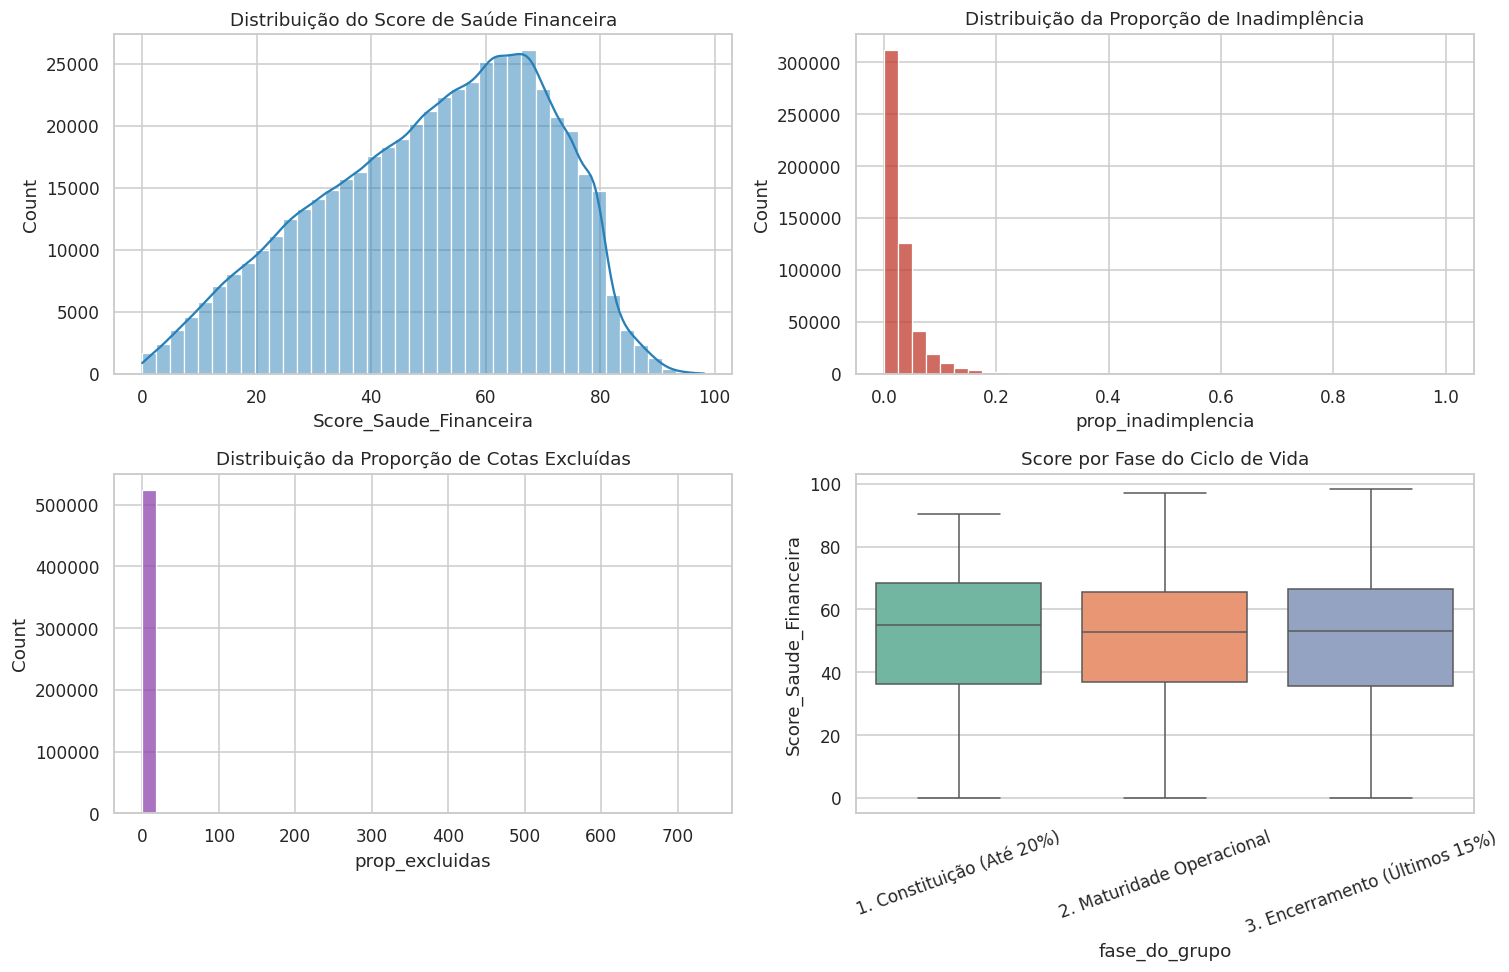

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(df_imoveis['Score_Saude_Financeira'], bins=40, kde=True, ax=axes[0, 0], color='#2980b9')
axes[0, 0].set_title('Distribuição do Score de Saúde Financeira')

sns.histplot(df_imoveis['prop_inadimplencia'], bins=40, ax=axes[0, 1], color='#c0392b')
axes[0, 1].set_title('Distribuição da Proporção de Inadimplência')

sns.histplot(df_imoveis['prop_excluidas'], bins=40, ax=axes[1, 0], color='#8e44ad')
axes[1, 0].set_title('Distribuição da Proporção de Cotas Excluídas')

sns.boxplot(data=df_imoveis, x='fase_do_grupo', y='Score_Saude_Financeira', ax=axes[1, 1],
            hue='fase_do_grupo', legend=False, palette='Set2')
axes[1, 1].set_title('Score por Fase do Ciclo de Vida')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [24]:
# Teste de normalidade (D'Agostino-Pearson) para as variaveis continuas
print("--- TESTE DE NORMALIDADE (D'Agostino-Pearson, alpha = 0,05) ---\n")
for col in ['prop_inadimplencia', 'prop_excluidas', 'Score_Saude_Financeira']:
    estat, p_valor = normaltest(df_imoveis[col])
    veredito = "Não normal" if p_valor < 0.05 else "Compatível com normal"
    print(f"{col:28s} | estatística = {estat:10.2f} | p = {p_valor:.4f} | {veredito}")

--- TESTE DE NORMALIDADE (D'Agostino-Pearson, alpha = 0,05) ---

prop_inadimplencia           | estatística =  512165.01 | p = 0.0000 | Não normal
prop_excluidas               | estatística = 1795114.24 | p = 0.0000 | Não normal
Score_Saude_Financeira       | estatística =   37101.06 | p = 0.0000 | Não normal


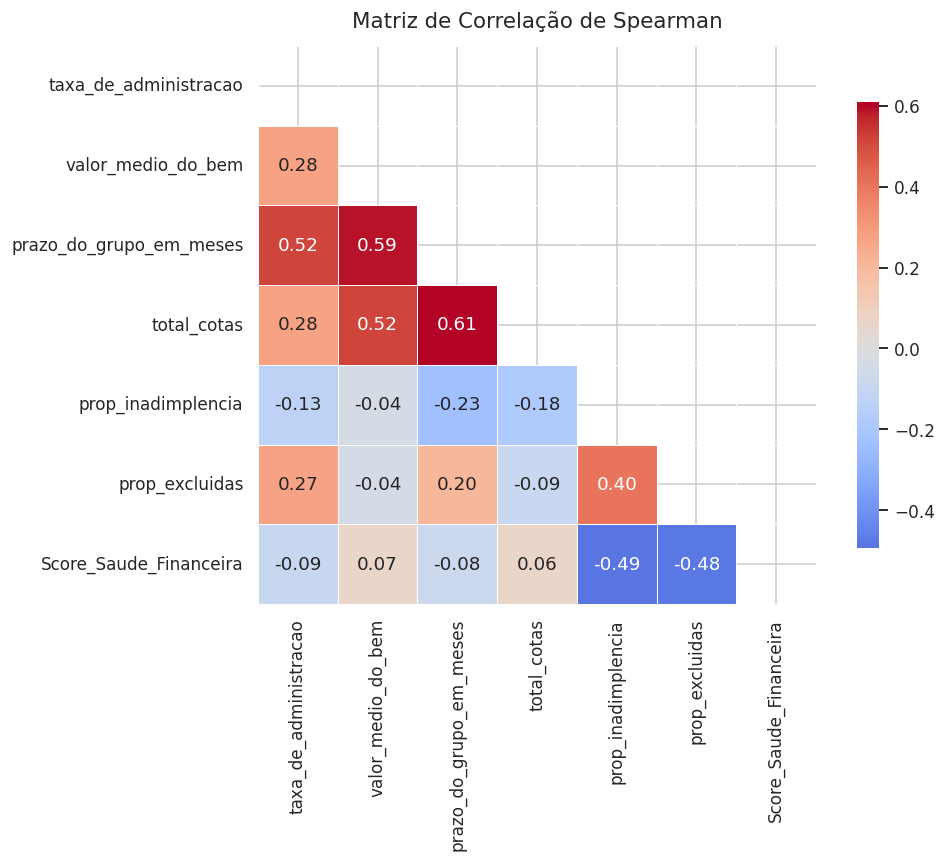

In [25]:
# Matriz de correlacao de Spearman (robusta a nao normalidade e outliers)
colunas_corr = [
    'taxa_de_administracao', 'valor_medio_do_bem', 'prazo_do_grupo_em_meses',
    'total_cotas', 'prop_inadimplencia', 'prop_excluidas', 'Score_Saude_Financeira'
]
matriz_corr = df_imoveis[colunas_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação de Spearman', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

In [27]:
# Associacao entre Fase do Grupo e Risco (Qui-quadrado de independencia + V de Cramer)
tabela_contingencia = pd.crosstab(df_imoveis['fase_do_grupo'], df_imoveis['target_em_risco'])
print("Tabela de contingência (Fase x Risco):")
print(tabela_contingencia, "\n")

chi2, p_valor, gl, esperado = chi2_contingency(tabela_contingencia)
n = tabela_contingencia.to_numpy().sum()
cramer_v = np.sqrt((chi2 / n) / (min(tabela_contingencia.shape) - 1))

print(f"Qui-quadrado = {chi2:.4f}")
print(f"Graus de liberdade = {gl}")
print(f"p-valor = {p_valor:.6f}")
print(f"V de Cramér = {cramer_v:.4f}")
print("Conclusão:", "Há associação significativa." if p_valor < 0.05 else "Sem associação significativa.")

Tabela de contingência (Fase x Risco):
target_em_risco                     0      1
fase_do_grupo                               
1. Constituição (Até 20%)      107156  44452
2. Maturidade Operacional      220142  91153
3. Encerramento (Últimos 15%)   43627  19477 

Qui-quadrado = 65.9502
Graus de liberdade = 2
p-valor = 0.000000
V de Cramér = 0.0112
Conclusão: Há associação significativa.


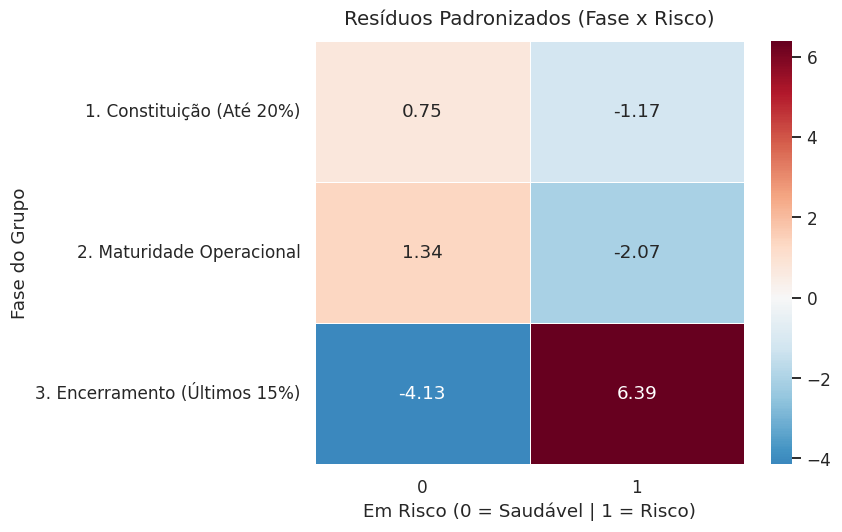

In [80]:
# Heatmap dos residuos padronizados (mostra QUAIS celulas puxam a associacao)
residuos = (tabela_contingencia - esperado) / np.sqrt(esperado)

plt.figure(figsize=(8, 5))
sns.heatmap(residuos, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Resíduos Padronizados (Fase x Risco)', fontsize=13, pad=10)
plt.xlabel('Em Risco (0 = Saudável | 1 = Risco)')
plt.ylabel('Fase do Grupo')
plt.tight_layout()
plt.show()

In [31]:
# Kruskal-Wallis: o Score difere entre as fases do ciclo de vida?
grupos_score = [
    grupo['Score_Saude_Financeira'].values
    for _, grupo in df_imoveis.groupby('fase_do_grupo', observed=True)
]
H, p_kruskal = kruskal(*grupos_score)

print("--- KRUSKAL-WALLIS: Score de Saúde por Fase ---")
print(f"Estatística H = {H:.4f}")
print(f"p-valor = {p_kruskal:.6f}")
print("Conclusão:", "Pelo menos uma fase difere das demais." if p_kruskal < 0.05 else "Sem diferença detectável entre as fases.")

print("\nMediana do Score por fase:")
print(df_imoveis.groupby('fase_do_grupo', observed=True)['Score_Saude_Financeira'].median().round(2))

--- KRUSKAL-WALLIS: Score de Saúde por Fase ---
Estatística H = 532.6600
p-valor = 0.000000
Conclusão: Pelo menos uma fase difere das demais.

Mediana do Score por fase:
fase_do_grupo
1. Constituição (Até 20%)        55.04
2. Maturidade Operacional        52.72
3. Encerramento (Últimos 15%)    53.21
Name: Score_Saude_Financeira, dtype: float64


In [32]:
# Mann-Whitney: grupos corrigidos por IPCA têm inadimplência diferente dos demais?
grupo_ipca = df_imoveis.loc[df_imoveis['indice_de_correcao'] == 'IPCA', 'prop_inadimplencia']
grupo_outros = df_imoveis.loc[df_imoveis['indice_de_correcao'] != 'IPCA', 'prop_inadimplencia']

if len(grupo_ipca) > 0 and len(grupo_outros) > 0:
    U, p_mw = mannwhitneyu(grupo_ipca, grupo_outros, alternative='two-sided')
    print("--- MANN-WHITNEY: Inadimplência (IPCA vs Demais Índices) ---")
    print(f"Estatística U = {U:.1f}")
    print(f"p-valor = {p_mw:.6f}")
    print(f"Mediana IPCA   = {grupo_ipca.median():.4f}")
    print(f"Mediana Demais = {grupo_outros.median():.4f}")
    print("Conclusão:", "Distribuições diferentes." if p_mw < 0.05 else "Sem diferença significativa.")
else:
    print("Sem registros suficientes para o teste.")

--- MANN-WHITNEY: Inadimplência (IPCA vs Demais Índices) ---
Estatística U = 13243340950.0
p-valor = 0.000000
Mediana IPCA   = 0.0417
Mediana Demais = 0.0187
Conclusão: Distribuições diferentes.


# Analisando a variável target


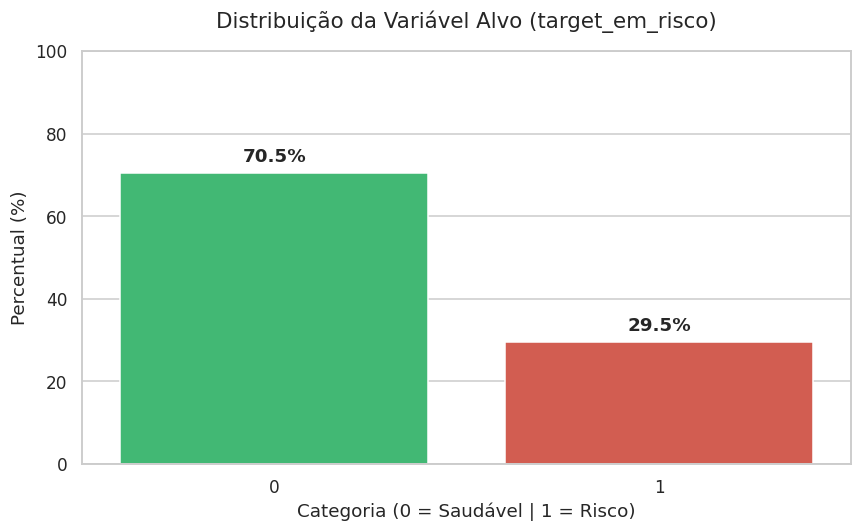

In [34]:
percentuais = df_imoveis['target_em_risco'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=percentuais.index.astype(str),
    y=percentuais.values,
    hue=percentuais.index.astype(str),
    legend=False,
    palette=['#2ecc71', '#e74c3c']
)

plt.title('Distribuição da Variável Alvo (target_em_risco)', fontsize=14, pad=15)
plt.xlabel('Categoria (0 = Saudável | 1 = Risco)', fontsize=12)
plt.ylabel('Percentual (%)', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Análises por administradora


In [36]:
# Recorte do mês mais recente disponível na base
data_mais_recente = df_imoveis['data_base'].max()
df_marco_2026 = df_imoveis[df_imoveis['data_base'] == data_mais_recente].copy()

print(f"Mês de referência: {data_mais_recente:%Y-%m}")
print(f"Registros nesse recorte: {len(df_marco_2026):,}")
print(f"CNPJs únicos na base completa: {df_imoveis['cnpj_da_administradora'].nunique()}")

Mês de referência: 2026-04
Registros nesse recorte: 2,601
CNPJs únicos na base completa: 184


In [37]:
# Resumo por administradora e fase do ciclo de vida
df_resumo = df_marco_2026.groupby(
    ['cnpj_da_administradora', 'fase_do_grupo'], observed=True
).agg(
    nome_da_administradora=('nome_da_administradora', 'last'),
    grupos_saudaveis=('target_em_risco', lambda x: (x == 0).sum()),
    grupos_risco=('target_em_risco', lambda x: (x == 1).sum()),
    total_grupos=('target_em_risco', 'count')
).reset_index()

df_resumo['pct_grupos_risco'] = (df_resumo['grupos_risco'] / df_resumo['total_grupos']) * 100
df_resumo = df_resumo.sort_values(['nome_da_administradora', 'fase_do_grupo']).reset_index(drop=True)
df_resumo['pct_grupos_risco_formatado'] = df_resumo['pct_grupos_risco'].map('{:.2f}%'.format)
df_resumo

,cnpj_da_administradora,fase_do_grupo,nome_da_administradora,grupos_saudaveis,grupos_risco,total_grupos,pct_grupos_risco,pct_grupos_risco_formatado
0,00000084911098,1. Constituição (Até 20%),ADEMICON ADM CONS S.A.,72,21,93,22.580645,22.58%
1,00000084911098,2. Maturidade Operacional,ADEMICON ADM CONS S.A.,9,24,33,72.727273,72.73%
2,00000084911098,3. Encerramento (Últimos 15%),ADEMICON ADM CONS S.A.,1,3,4,75.000000,75.00%
3,00000003828278,2. Maturidade Operacional,ADM CONS BECKER LTDA,4,2,6,33.333333,33.33%
4,00000007808907,1. Constituição (Até 20%),ADM CONS SICREDI LTDA,36,13,49,26.530612,26.53%
5,00000007808907,2. Maturidade Operacional,ADM CONS SICREDI LTDA,35,23,58,39.655172,39.66%
6,00000007808907,3. Encerramento (Últimos 15%),ADM CONS SICREDI LTDA,3,0,3,0.000000,0.00%
7,00000091341925,1. Constituição (Até 20%),ADM CONS SPENGLER LTDA,0,1,1,100.000000,100.00%
8,00000091341925,2. Maturidade Operacional,ADM CONS SPENGLER LTDA,1,0,1,0.000000,0.00%
9,00000012228808,1. Constituição (Até 20%),ADM CONS UNICOOB LTDA,4,0,4,0.000000,0.00%


In [38]:
# Visão executiva: percentual de grupos em risco por fase e administradora
visao_executiva = df_resumo.pivot_table(
    index='nome_da_administradora',
    columns='fase_do_grupo',
    values='pct_grupos_risco',
    aggfunc='sum',
    observed=True
).fillna(0)

visao_formatada = visao_executiva.map(lambda x: f"{x:.2f}%")
print("--- PERCENTUAL DE GRUPOS EM RISCO POR FASE E ADMINISTRADORA ---")
display(visao_formatada)

--- PERCENTUAL DE GRUPOS EM RISCO POR FASE E ADMINISTRADORA ---


fase_do_grupo,1. Constituição (Até 20%),2. Maturidade Operacional,3. Encerramento (Últimos 15%)
nome_da_administradora,,,
ADEMICON ADM CONS S.A.,22.58%,72.73%,75.00%
ADM CONS BECKER LTDA,0.00%,33.33%,0.00%
ADM CONS SICREDI LTDA,26.53%,39.66%,0.00%
ADM CONS SPENGLER LTDA,100.00%,0.00%,0.00%
ADM CONS UNICOOB LTDA,0.00%,41.67%,0.00%
ALPHA ADM CONS LTDA,0.00%,50.00%,0.00%
BAMAQ ADM CONS LTDA,0.00%,0.00%,0.00%
BANCORBRÁS,0.00%,0.00%,0.00%
BANRISUL S.A. ADM CONSÓRCIOS,75.00%,83.87%,71.43%


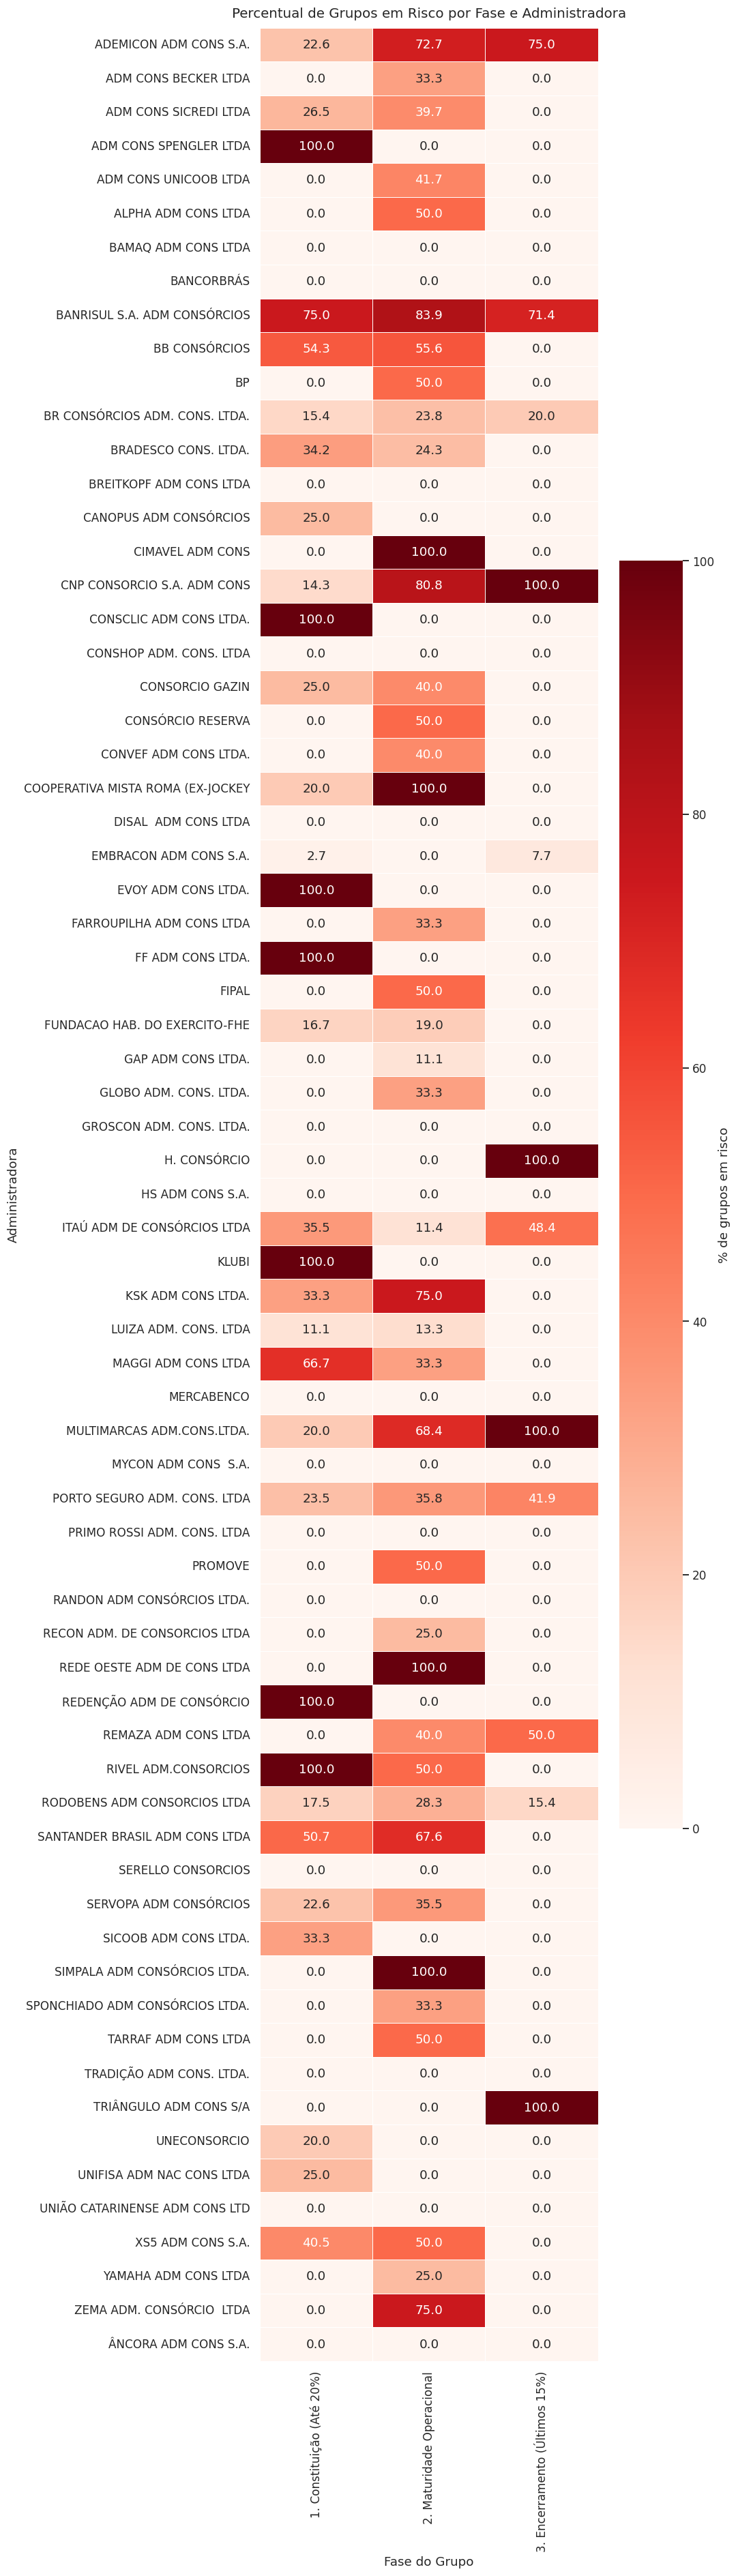

In [40]:
# Heatmap da visao executiva
plt.figure(figsize=(10, max(4, 0.5 * len(visao_executiva))))
sns.heatmap(visao_executiva, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5,
            cbar_kws={'label': '% de grupos em risco'})
plt.title('Percentual de Grupos em Risco por Fase e Administradora', fontsize=13, pad=10)
plt.xlabel('Fase do Grupo')
plt.ylabel('Administradora')
plt.tight_layout()
plt.show()

In [41]:
# Grupos com alta rotatividade: exclusões superam a base de cotas ativas
df_grupos_alta_rotatividade = df_marco_2026[df_marco_2026['prop_excluidas'] > 1.0].copy()

colunas_detalhe = [
    'nome_da_administradora', 'grupo', 'total_cotas_ativas',
    'quantidade_de_cotas_excluidas', 'prop_excluidas'
]

df_detalhe_rotatividade = (
    df_grupos_alta_rotatividade[colunas_detalhe]
    .sort_values(['nome_da_administradora', 'prop_excluidas'], ascending=[True, False])
    .reset_index(drop=True)
)
df_detalhe_rotatividade['prop_excluidas'] = df_detalhe_rotatividade['prop_excluidas'].round(2)

print(f"--- {len(df_detalhe_rotatividade)} GRUPOS COM EXCLUSÕES > ATIVAS ---")
df_detalhe_rotatividade.head(15)

--- 1408 GRUPOS COM EXCLUSÕES > ATIVAS ---


,nome_da_administradora,grupo,total_cotas_ativas,quantidade_de_cotas_excluidas,prop_excluidas
0,ADEMICON ADM CONS S.A.,00420,1984,4863,2.04
1,ADEMICON ADM CONS S.A.,00590,1882,3362,1.76
2,ADEMICON ADM CONS S.A.,00570,1866,3285,1.73
3,ADEMICON ADM CONS S.A.,00730,3156,5420,1.71
4,ADEMICON ADM CONS S.A.,00630,1864,3226,1.71
5,ADEMICON ADM CONS S.A.,00611,1928,3328,1.71
6,ADEMICON ADM CONS S.A.,00640,1875,3248,1.70
7,ADEMICON ADM CONS S.A.,00651,3086,5068,1.64
8,ADEMICON ADM CONS S.A.,00370,985,2109,1.63
9,ADEMICON ADM CONS S.A.,00520,1963,3357,1.62


In [42]:
# Ranking de administradoras pelo cenário de exclusões (pior para o melhor)
df_resumo_admin = df_grupos_alta_rotatividade.groupby(
    'nome_da_administradora', observed=True
).agg(
    qtd_grupos_nesta_situacao=('grupo', 'count'),
    soma_cotas_ativas=('total_cotas_ativas', 'sum'),
    soma_cotas_excluidas=('quantidade_de_cotas_excluidas', 'sum')
).reset_index()

df_resumo_admin['proporcao_media_exclusao'] = (
    df_resumo_admin['soma_cotas_excluidas'] / df_resumo_admin['soma_cotas_ativas'].replace(0, np.nan)
).round(2)

df_resumo_admin = df_resumo_admin.sort_values(
    ['proporcao_media_exclusao', 'soma_cotas_excluidas'], ascending=[False, False]
).reset_index(drop=True)

print("--- RANKING: ADMINISTRADORAS DO PIOR PARA O MELHOR CENÁRIO ---")
display(df_resumo_admin)

--- RANKING: ADMINISTRADORAS DO PIOR PARA O MELHOR CENÁRIO ---


,nome_da_administradora,qtd_grupos_nesta_situacao,soma_cotas_ativas,soma_cotas_excluidas,proporcao_media_exclusao
0,MULTIMARCAS ADM.CONS.LTDA.,31,9965,115883,11.63
1,COOPERATIVA MISTA ROMA (EX-JOCKEY,5,1691,18449,10.91
2,ZEMA ADM. CONSÓRCIO LTDA,13,7444,62419,8.39
3,CONSÓRCIO RESERVA,3,1655,13537,8.18
4,H. CONSÓRCIO,1,122,956,7.84
5,CIMAVEL ADM CONS,1,155,1175,7.58
6,DISAL ADM CONS LTDA,1,102,737,7.23
7,FARROUPILHA ADM CONS LTDA,3,2503,17210,6.88
8,ALPHA ADM CONS LTDA,2,3046,19914,6.54
9,GROSCON ADM. CONS. LTDA.,1,662,3694,5.58


In [43]:
# Estudo de caso: BB Consórcios (CNPJ iniciado em 00000006043050)
filtro_bb = df_marco_2026['cnpj_da_administradora'].astype(str).str.startswith('00000006043050')
df_bb = df_marco_2026[filtro_bb].copy()
print(f"Grupos da BB Consórcios em {data_mais_recente:%Y-%m}: {len(df_bb)}")

resumo_fases_bb = pd.crosstab(
    index=df_bb['fase_do_grupo'],
    columns=df_bb['target_em_risco'],
    margins=True,
    margins_name='Total'
).rename(columns={0: 'Saudável (0)', 1: 'Risco (1)'})

if 'Risco (1)' in resumo_fases_bb.columns:
    resumo_fases_bb['%_de_Risco'] = (resumo_fases_bb['Risco (1)'] / resumo_fases_bb['Total'] * 100).map('{:.2f}%'.format)

display(resumo_fases_bb)

Grupos da BB Consórcios em 2026-04: 82


target_em_risco,Saudável (0),Risco (1),Total,%_de_Risco
fase_do_grupo,,,,
1. Constituição (Até 20%),21,25,46,54.35%
2. Maturidade Operacional,16,20,36,55.56%
Total,37,45,82,54.88%


In [44]:
# Relatório detalhado dos grupos da BB Consórcios, do mais crítico ao mais saudável
df_bb_marco = df_marco_2026[filtro_bb].copy()
df_bb_marco['status_saude'] = np.where(df_bb_marco['target_em_risco'] == 1, 'Em Risco', 'Saudável')

colunas_relatorio = [
    'nome_da_administradora', 'grupo', 'numero_da_assembleia_geral_ordinaria',
    'prazo_do_grupo_em_meses', 'fase_do_grupo', 'Score_Saude_Financeira', 'status_saude'
]

df_grupos_bb_final = (
    df_bb_marco[colunas_relatorio]
    .sort_values(['fase_do_grupo', 'status_saude', 'Score_Saude_Financeira'],
                 ascending=[True, False, True])
    .reset_index(drop=True)
)
df_grupos_bb_final.head(30)

,nome_da_administradora,grupo,numero_da_assembleia_geral_ordinaria,prazo_do_grupo_em_meses,fase_do_grupo,Score_Saude_Financeira,status_saude
0,BB CONSÓRCIOS,01671,30,240,1. Constituição (Até 20%),40.554576,Saudável
1,BB CONSÓRCIOS,01642,34,240,1. Constituição (Até 20%),41.104141,Saudável
2,BB CONSÓRCIOS,01673,30,240,1. Constituição (Até 20%),41.321723,Saudável
3,BB CONSÓRCIOS,01686,27,240,1. Constituição (Até 20%),46.847398,Saudável
4,BB CONSÓRCIOS,01735,17,180,1. Constituição (Até 20%),56.293828,Saudável
5,BB CONSÓRCIOS,01699,24,240,1. Constituição (Até 20%),61.584056,Saudável
6,BB CONSÓRCIOS,01718,21,240,1. Constituição (Até 20%),63.641272,Saudável
7,BB CONSÓRCIOS,01731,17,180,1. Constituição (Até 20%),64.366018,Saudável
8,BB CONSÓRCIOS,01738,16,180,1. Constituição (Até 20%),67.426444,Saudável
9,BB CONSÓRCIOS,01753,12,180,1. Constituição (Até 20%),68.318953,Saudável


# Salvamento da base tratada


In [47]:
caminho_salvamento = os.path.join(os.getcwd(), "df_limpo.csv")

df_imoveis.to_csv(
    caminho_salvamento,
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

print(f"Dimensões finais: {df_imoveis.shape[0]:,} linhas x {df_imoveis.shape[1]} colunas")

Base tratada salva em: C:\Users\Sergio\df_limpo.csv
Dimensões finais: 526,007 linhas x 29 colunas
